In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def spred_func(n,mas):
    y = np.arange(1, n+1) / n

    plt.step(mas, y, where='post', linewidth=2)
    plt.scatter(mas, y, color='red', s=50)

    plt.xlabel('x')
    plt.ylabel('F_n(x)')
    plt.title('Эмпирическая функция распределения')
    plt.grid(True)
    plt.ylim(0, 1.1)
    plt.show()

def calculate_stats(n,data_sorted):

    #выборочное среднее
    vub_avg = sum(data_sorted) / n

    #дисперсии
    #смещенная (делим на n)
    var_biased = sum((x - vub_avg)**2 for x in data_sorted) / n

    #несмещенная (делим на n-1)
    var_unbiased = sum((x - vub_avg)**2 for x in data_sorted) / (n - 1)

    #стандартные отклонения
    std_biased = var_biased ** 0.5
    std_unbiased = var_unbiased ** 0.5

    #медиана
    if n % 2 == 1:
        median = data_sorted[n // 2]
    else:
        median = (data_sorted[n // 2 - 1] + data_sorted[n // 2]) / 2

    #квартили
    q1_index = int(n * 0.25)
    q3_index = int(n * 0.75)
    q1 = data_sorted[q1_index]
    q3 = data_sorted[q3_index]

    stats = {
        'n': n,
        'vub_avg': vub_avg,
        'var_biased': var_biased,
        'var_unbiased': var_unbiased,
        'std_biased': std_biased,
        'std_unbiased': std_unbiased,
        'median': median,
        'q1': q1,
        'q3': q3,
        'min': data_sorted[0],
        'max': data_sorted[-1],
        'range': data_sorted[-1] - data_sorted[0]
    }

    return stats

#Гистограмма с правилом Скотта: h = 3.5 * S * n^(-1/3)
def hist_scott(n,data,std_unbiased):

    #ширина интервала
    h = 3.5 * std_unbiased * n**(-1/3)

    #число интервалов
    k = int((max(data) - min(data)) / h) + 1

    plt.hist(data, bins=k, edgecolor='black')
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.title(f'Правило Скотта (интервалов = {k})')
    plt.grid(True, alpha=0.3)
    plt.show()

    return k


#Гистограмма с правилом Фридмана-Диакониса: h = 2 * IQR * n^(-1/3)
def hist_fd(n,data, q1,q3):

    iqr = q3 - q1

    #ширина интервала
    h = 2 * iqr * n**(-1/3)

    #число интервалов
    k = int((max(data) - min(data)) / h) + 1

    plt.hist(data, bins=k, edgecolor='black')
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.title(f'Правило Фридмана-Диакониса (интервалов = {k})')
    plt.grid(True, alpha=0.3)
    plt.show()

    return k

#оценка нормального распределения методами мм и ммп
def estimate_normal(data):
    n = len(data)
    mean = sum(data) / n
    var = sum((x - mean)**2 for x in data) / n
    S = var ** 0.5 # выборочное стандартное отклонение

    # метод моментов
    a_mm = mean
    sigma_mm = S

    # метод максимального правдоподобия
    a_mle = mean
    sigma_mle = S

    return {
        "MM": (a_mm, sigma_mm),
        "MLE": (a_mle, sigma_mle)
    }

# оценка равномерного распределения
def estimate_uniform(data):
    n = len(data)
    mean = sum(data) / n
    var = sum((x - mean)**2 for x in data) / n
    S = var ** 0.5

    # MM
    a_mm = mean - (3 * var) ** 0.5
    b_mm = mean + (3 * var) ** 0.5

    # ММП
    a_mle = min(data)
    b_mle = max(data)

    return {
        "MM": (a_mm, b_mm),
        "MLE": (a_mle, b_mle)
    }

#оценка экспоненциального распределения
def estimate_exponential(data):
    n = len(data)
    mean = sum(data) / n
    var = sum((x - mean)**2 for x in data) / n
    S = var ** 0.5

    # MM
    lam_mm = 1 / S
    c_mm = mean - (1 / lam_mm)

    #ММП
    c_mle = min(data)
    lam_mle = 1 / (mean - c_mle)

    return {
        "MM": {"lambda": lam_mm, "c": c_mm},
        "MLE": {"lambda": lam_mle, "c": c_mle}
    }

#сравнивает оценки
def compare(name, result):

    print("\n", name)

    print("Метод моментов:", result["MM"])
    print("Метод максимального правдоподобия:", result["MLE"])

#функция для анализа одного ряда(пункт 1-2)
def analyze_one(data):
    #вариационный ряд
    sorted_data=sorted(data)
    n=200

    #вызывают ффункцию для функции распределения
    spred_func(n,sorted_data)

    #считаем основные значения
    stats = calculate_stats(n,sorted_data)
    print(stats)

    #строим гистограммы
    q1=stats['q1']
    q3=stats['q3']
    std_unbiased=stats['std_unbiased']

    hist_scott(n,sorted_data,std_unbiased)
    hist_fd(n,data,q1,q3)

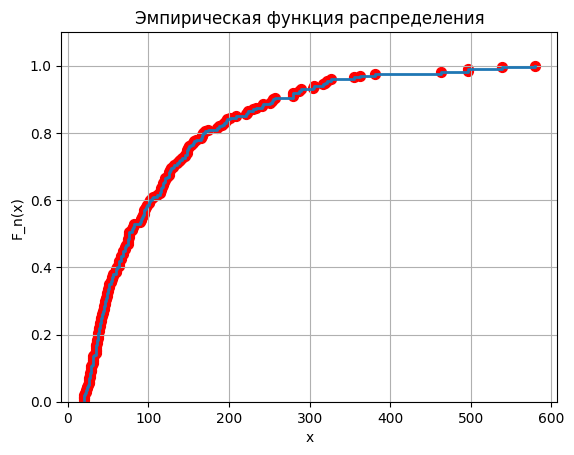

{'n': 200, 'vub_avg': 115.93979999999999, 'var_biased': 10866.09967796, 'var_unbiased': 10920.703193929648, 'std_biased': 104.2405855603277, 'std_unbiased': 104.50216836951111, 'median': 75.91499999999999, 'q1': 42.42, 'q3': 148.65, 'min': 19.97, 'max': 579.58, 'range': 559.61}


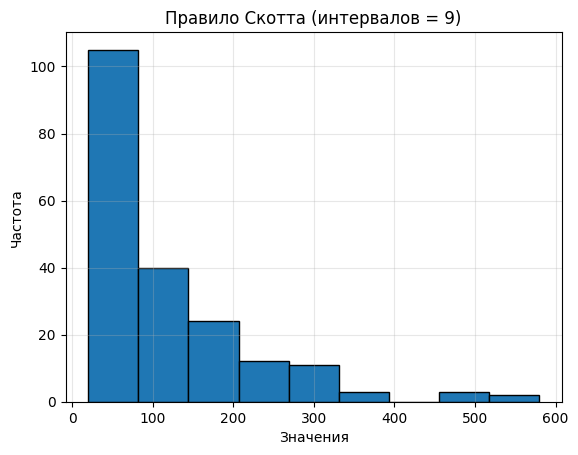

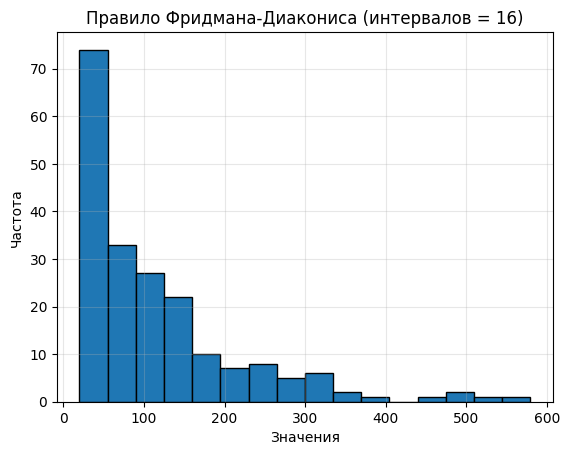

19.97
579.58


In [ ]:
X1,X2,X3,X4 = [],[],[],[]

with open('RGR1_A-5_X1-X4.csv', 'r') as file:
    reader = csv.reader((file))
    next(reader)
    for row in file:
        temp = row.split(",")
        if (temp[0]=="X1"):
            break
        X1.append(float(temp[0]))
        X2.append(float(temp[1]))
        X3.append(float(temp[2]))
        X4.append(float(temp[3]))

analyze_one(X1)
print(min(X1))
print(max(X1))

In [ ]:
print(sorted(X1))

[19.97, 20.01, 20.08, 20.15, 20.76, 22.09, 22.28, 23.65, 24.02, 24.44, 25.72, 25.77, 25.99, 26.34, 27.13, 27.64, 27.67, 28.09, 28.34, 28.96, 29.05, 30.26, 30.76, 30.99, 31.19, 31.31, 31.47, 32.19, 34.41, 34.52, 34.56, 34.78, 34.88, 35.09, 35.7, 36.52, 36.73, 36.87, 37.16, 37.21, 37.65, 38.21, 38.46, 38.68, 39.56, 40.45, 40.49, 40.6, 40.82, 41.65, 42.42, 42.58, 43.29, 44.05, 44.83, 45.1, 45.37, 45.63, 45.76, 46.68, 47.06, 47.84, 48.28, 48.54, 49.14, 49.73, 50.05, 50.83, 50.89, 51.1, 53.51, 53.66, 54.56, 54.57, 55.71, 56.43, 59.12, 59.45, 59.72, 60.8, 62.87, 62.96, 63.44, 64.03, 65.35, 66.16, 66.49, 68.15, 68.24, 68.76, 70.58, 70.98, 72.44, 74.28, 74.86, 74.93, 75.14, 75.26, 75.36, 75.51, 76.32, 79.81, 80.1, 80.62, 81.79, 82.34, 89.76, 90.28, 90.77, 91.54, 93.7, 94.08, 94.17, 94.73, 95.92, 97.19, 98.57, 100.86, 101.07, 101.61, 104.46, 105.47, 110.01, 113.98, 114.77, 115.67, 116.12, 116.52, 117.8, 118.66, 119.6, 120.46, 121.09, 123.57, 124.91, 125.22, 125.87, 126.72, 128.05, 130.73, 132.1

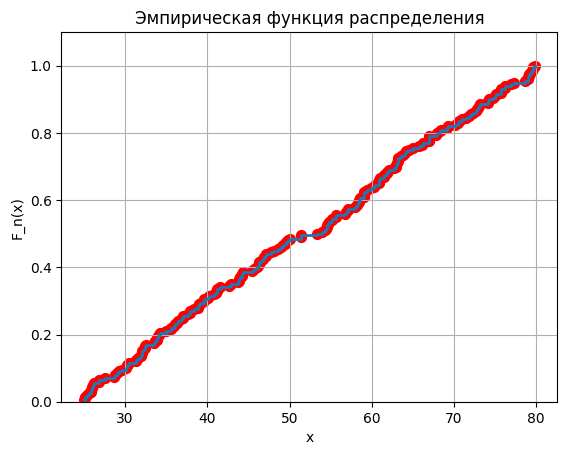

{'n': 200, 'vub_avg': 51.8794, 'var_biased': 266.35612763999995, 'var_unbiased': 267.69460064321606, 'std_biased': 16.320420571786745, 'std_unbiased': 16.361375267477243, 'median': 53.629999999999995, 'q1': 37.08, 'q3': 65.03, 'min': 24.99, 'max': 79.85, 'range': 54.86}


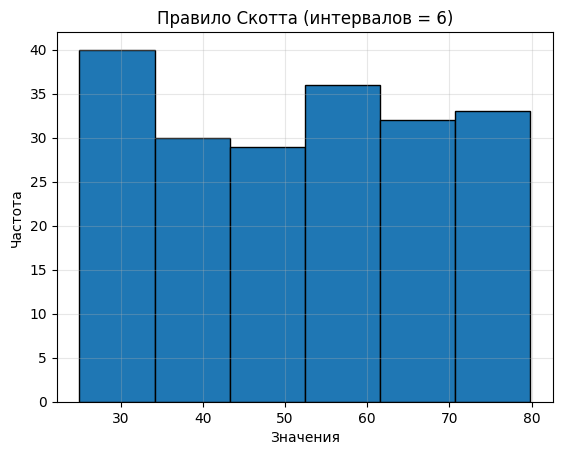

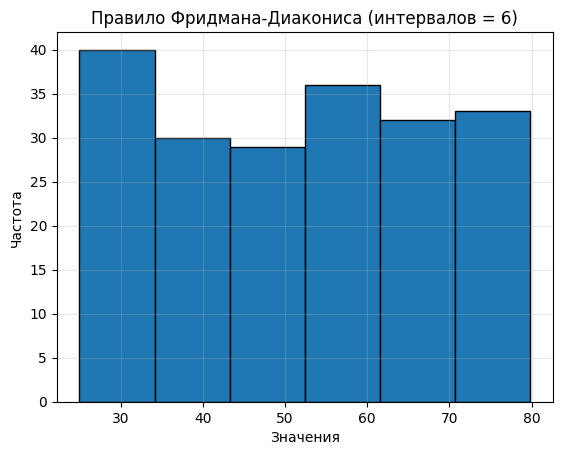

In [ ]:
analyze_one(X2)


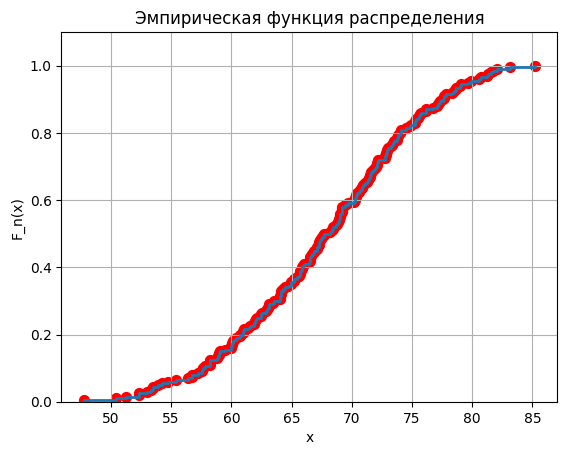

{'n': 200, 'vub_avg': 67.69585000000001, 'var_biased': 56.56736827749999, 'var_unbiased': 56.85162640954773, 'std_biased': 7.5211281253213595, 'std_unbiased': 7.540001751296065, 'median': 67.98, 'q1': 62.43, 'q3': 73.02, 'min': 47.76, 'max': 85.21, 'range': 37.449999999999996}


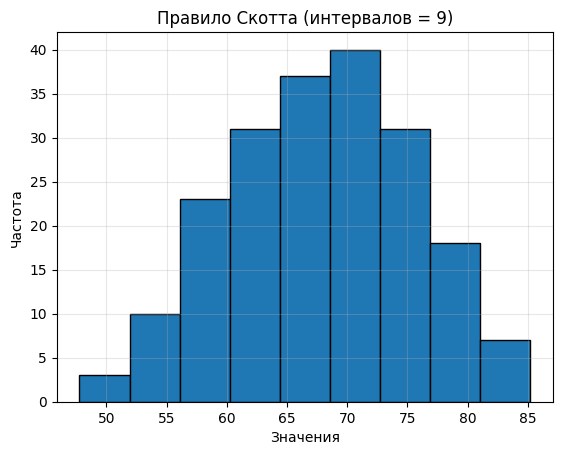

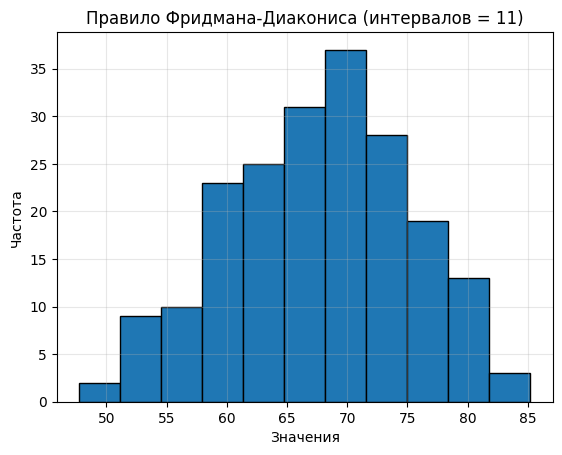

In [ ]:
analyze_one(X3)